# Ejercicio


# Fase 1: Exploración y Limpieza

. Exploración Inicial:
- Realiza una exploración inicial de los datos para identificar posibles problemas, como valores nulos, atípicos o datos faltantes en las columnas relevantes --> head, tail, sample, info
- Utiliza funciones de Pandas para obtener información sobre la estructura de los datos, la presencia de valores nulos y estadísticas básicas de las columnas involucradas.
- Une los dos conjuntos de datos de la forma más eficiente.

. Limpieza de Datos:
- Elimina o trata los valores nulos, si los hay, en las columnas clave para asegurar que los datos estén completos.
- Verifica la consistencia y corrección de los datos para asegurarte de que los datos se presenten de forma coherente.
- Realiza cualquier ajuste o conversión necesaria en las columnas (por ejemplo, cambiar tipos de datos) para garantizar la adecuación de los datos para el análisis estadístico

In [1]:
import pandas as pd
import numpy as numpy
pd.set_option("display.max_columns", None)
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Realiza una exploración inicial de los datos para identificar posibles problemas, como valores nulos, atípicos o datos faltantes en las columnas relevantes.

def exploracion_inicial(df):
    display(df.head(2))
    print("=" * 100)
    display(df.tail(2))
    print("=" * 100)
    display(df.sample(2))
    print("=" * 100)
    print(df.info())
    print("=" * 100)
    print(" " * 100)
    print(f"El dataframe history tiene {df.shape[0]} filas y {df.shape[1]} columnas")


In [3]:
# DataFrame 1 

df_history = pd.read_csv("Customer_Loyalty_History.csv")

exploracion_inicial(df_history)

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN
16736,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049.0,Married,Star,83325.38,Standard,2015,12,2016.0,8.0


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
4693,413088,Canada,Quebec,Montreal,H2Y 4R4,Male,Doctor,266870.0,Married,Nova,3033.41,Standard,2014,9,NaN,NaN
11053,618494,Canada,Ontario,Toronto,M2M 7K8,Female,College,NaN,Single,Star,2555.05,Standard,2017,9,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  object 
 2   Province            16737 non-null  object 
 3   City                16737 non-null  object 
 4   Postal Code         16737 non-null  object 
 5   Gender              16737 non-null  object 
 6   Education           16737 non-null  object 
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  object 
 9   Loyalty Card        16737 non-null  object 
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  object 
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: f

In [4]:
# DataFrame 2

df_activity = pd.read_csv("Customer_flight_activity.csv")

exploracion_inicial(df_activity)

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
405622,999982,2018,12,0,0,0,0,0.0,0,0
405623,999986,2018,12,0,0,0,0,0.0,0,0


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
377135,384286,2018,11,0,0,0,0,0.0,0,0
40114,437086,2017,3,13,0,13,1378,137.0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB
None
                                                                                                    
El dataframe history tie

LIMPIEZA PENSADA DESPUÉS DE LAS PRIMERAS REVISIONES:

1. Nombre se las columnas en minuscula, separar palabras con _ y guardar

2. Conversion tipos de dato:
- df_history: Salary a int
- df_history: cancellation month y year a int
- df_activity: points redeemed a float para igualarlo con points accumulated

3. Eliminar duplicados

4. gestionar nulos: df_history: salary, cancellation year y month

5. gestion numeros negativos en salary

6. guardar df limpios + nuevo df unido

In [5]:
# añadir _ a los nombres de las columnas y poner en minúscula
# 1. ver las columnas

df_history.columns

Index(['Loyalty Number', 'Country', 'Province', 'City', 'Postal Code',
       'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card',
       'CLV', 'Enrollment Type', 'Enrollment Year', 'Enrollment Month',
       'Cancellation Year', 'Cancellation Month'],
      dtype='object')

In [6]:
# 2. añadir _ y poner en minúscula

col_nuevas_history = {col: col.lower().replace(" ", "_") for col in df_history.columns}   

col_nuevas_history

{'Loyalty Number': 'loyalty_number',
 'Country': 'country',
 'Province': 'province',
 'City': 'city',
 'Postal Code': 'postal_code',
 'Gender': 'gender',
 'Education': 'education',
 'Salary': 'salary',
 'Marital Status': 'marital_status',
 'Loyalty Card': 'loyalty_card',
 'CLV': 'clv',
 'Enrollment Type': 'enrollment_type',
 'Enrollment Year': 'enrollment_year',
 'Enrollment Month': 'enrollment_month',
 'Cancellation Year': 'cancellation_year',
 'Cancellation Month': 'cancellation_month'}

In [7]:
# comprobando. al hacer esto, el df original sigue siendo como era

df_history

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN


In [8]:
# para aplicar los cambios:

df_history.rename(columns= col_nuevas_history, inplace=True)

df_history.head(2)


,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


In [9]:
df_activity.columns

Index(['Loyalty Number', 'Year', 'Month', 'Flights Booked',
       'Flights with Companions', 'Total Flights', 'Distance',
       'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed'],
      dtype='object')

In [10]:
col_nuevas_activity = {col: col.lower().replace(" ", "_") for col in df_activity.columns}   

col_nuevas_activity

{'Loyalty Number': 'loyalty_number',
 'Year': 'year',
 'Month': 'month',
 'Flights Booked': 'flights_booked',
 'Flights with Companions': 'flights_with_companions',
 'Total Flights': 'total_flights',
 'Distance': 'distance',
 'Points Accumulated': 'points_accumulated',
 'Points Redeemed': 'points_redeemed',
 'Dollar Cost Points Redeemed': 'dollar_cost_points_redeemed'}

In [11]:
df_activity.rename(columns= col_nuevas_activity, inplace=True)

df_activity.head(2)


,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0


In [12]:
# Cambio tioo de dato

columnas_a_entero = ['salary', 'cancellation_month', 'cancellation_year']

for col in columnas_a_entero:
    df_history[col] = df_history[col].astype('Int64')

df_history[columnas_a_entero].dtypes

salary                Int64
cancellation_month    Int64
cancellation_year     Int64
dtype: object

In [13]:
# comprobacion
df_history.sample(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
10627,908643,Canada,Ontario,Toronto,M1R 4K3,Male,College,<NA>,Single,Star,2470.12,Standard,2017,10,<NA>,<NA>
9804,191065,Canada,Ontario,Toronto,P5S 6R4,Male,Bachelor,79034,Single,Nova,46770.95,Standard,2016,12,<NA>,<NA>


In [14]:
# ver nombres de las columnas
df_activity.columns

Index(['loyalty_number', 'year', 'month', 'flights_booked',
       'flights_with_companions', 'total_flights', 'distance',
       'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed'],
      dtype='object')

In [15]:
# cambio tipo de dato

columnas_a_float = ['points_redeemed']

for col in columnas_a_float:
    df_activity[col] = df_activity[col].astype('float64')

df_activity[columnas_a_float].dtypes

points_redeemed    float64
dtype: object

In [16]:
# comprobacion 1
df_activity.sample(2)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
134671,401956,2018,6,13,0,13,1560,156.0,0.0,0
289779,232685,2018,6,0,0,0,0,0.0,0.0,0


In [17]:
# comprobacion 2
df_history.dtypes

loyalty_number          int64
country                object
province               object
city                   object
postal_code            object
gender                 object
education              object
salary                  Int64
marital_status         object
loyalty_card           object
clv                   float64
enrollment_type        object
enrollment_year         int64
enrollment_month        int64
cancellation_year       Int64
cancellation_month      Int64
dtype: object

In [18]:
# comprobacion 3
df_activity.dtypes

loyalty_number                   int64
year                             int64
month                            int64
flights_booked                   int64
flights_with_companions          int64
total_flights                    int64
distance                         int64
points_accumulated             float64
points_redeemed                float64
dollar_cost_points_redeemed      int64
dtype: object

In [19]:
# comprobacion 4
df_history

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,<NA>,<NA>
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,<NA>,Divorced,Star,3839.61,Standard,2016,3,<NA>,<NA>
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,<NA>,Single,Star,3839.75,Standard,2014,7,2018,1
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,<NA>,Single,Star,3839.75,Standard,2013,2,<NA>,<NA>
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495,Married,Star,3842.79,Standard,2014,10,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,<NA>,Married,Star,61850.19,Standard,2012,12,<NA>,<NA>
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210,Married,Star,67907.27,Standard,2014,9,<NA>,<NA>
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,<NA>,Single,Star,74228.52,Standard,2014,3,<NA>,<NA>
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297,Married,Star,10018.66,2018 Promotion,2018,4,<NA>,<NA>


In [20]:
# comprobacion 5
df_activity

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,1,3,0,3,1521,152.0,0.0,0
1,100102,2017,1,10,4,14,2030,203.0,0.0,0
2,100140,2017,1,6,0,6,1200,120.0,0.0,0
3,100214,2017,1,0,0,0,0,0.0,0.0,0
4,100272,2017,1,0,0,0,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...
405619,999902,2018,12,0,0,0,0,0.0,0.0,0
405620,999911,2018,12,0,0,0,0,0.0,0.0,0
405621,999940,2018,12,3,0,3,1233,123.0,0.0,0
405622,999982,2018,12,0,0,0,0,0.0,0.0,0


In [21]:
# history
# numericas

df_history.describe(include= "number").T

,count,mean,std,min,25%,50%,75%,max
loyalty_number,16737.0,549735.880445,258912.132453,100018.0,326603.0,550434.0,772019.0,999986.0
salary,12499.0,79245.609409,35008.297285,-58486.0,59246.5,73455.0,88517.5,407228.0
clv,16737.0,7988.896536,6860.98228,1898.01,3980.84,5780.18,8940.58,83325.38
enrollment_year,16737.0,2015.253211,1.979111,2012.0,2014.0,2015.0,2017.0,2018.0
enrollment_month,16737.0,6.669116,3.398958,1.0,4.0,7.0,10.0,12.0
cancellation_year,2067.0,2016.503145,1.380743,2013.0,2016.0,2017.0,2018.0,2018.0
cancellation_month,2067.0,6.962748,3.455297,1.0,4.0,7.0,10.0,12.0


In [22]:
# history
# categoricas

df_history.describe(include="object").T

,count,unique,top,freq
country,16737,1,Canada,16737
province,16737,11,Ontario,5404
city,16737,29,Toronto,3351
postal_code,16737,55,V6E 3D9,911
gender,16737,2,Female,8410
education,16737,5,Bachelor,10475
marital_status,16737,3,Married,9735
loyalty_card,16737,3,Star,7637
enrollment_type,16737,2,Standard,15766


In [23]:
col_cat_history = df_history.select_dtypes(include="object").columns

col_cat_history

Index(['country', 'province', 'city', 'postal_code', 'gender', 'education',
       'marital_status', 'loyalty_card', 'enrollment_type'],
      dtype='object')

In [24]:
# recorrer cada columna para ver cuales son sus categorías

for col in col_cat_history:
    print(f"Categorias columna ¨{col}")
    print(df_history[col].unique())
    print("=" * 100)


Categorias columna ¨country
['Canada']
Categorias columna ¨province
['Ontario' 'Alberta' 'British Columbia' 'Quebec' 'Yukon' 'New Brunswick'
 'Manitoba' 'Nova Scotia' 'Saskatchewan' 'Newfoundland'
 'Prince Edward Island']
Categorias columna ¨city
['Toronto' 'Edmonton' 'Vancouver' 'Hull' 'Whitehorse' 'Trenton' 'Montreal'
 'Dawson Creek' 'Quebec City' 'Fredericton' 'Ottawa' 'Tremblant' 'Calgary'
 'Thunder Bay' 'Whistler' 'Peace River' 'Winnipeg' 'Sudbury'
 'West Vancouver' 'Halifax' 'London' 'Regina' 'Kelowna' "St. John's"
 'Victoria' 'Kingston' 'Banff' 'Moncton' 'Charlottetown']
Categorias columna ¨postal_code
['M2Z 4K1' 'T3G 6Y6' 'V6E 3D9' 'P1W 1K4' 'J8Y 3Z5' 'Y2K 6R0' 'P5S 6R4'
 'K8V 4B2' 'H2Y 2W2' 'M8Y 4K8' 'U5I 4F1' 'G1B 3L5' 'H4G 3T4' 'M2M 7K8'
 'M2M 6J7' 'E3B 2H2' 'M1R 4K3' 'T9G 1W3' 'H2Y 4R4' 'V5R 1W3' 'P1L 8X8'
 'K1F 2R2' 'H5Y 2S9' 'V1E 4R6' 'H2T 2J6' 'T3E 2V9' 'H2T 9K8' 'K8T 5M5'
 'V6T 1Y8' 'P2T 6G3' 'T9O 2W2' 'V6E 3Z3' 'R6Y 4T5' 'M5V 1G5' 'V6V 8Z3'
 'B3J 9S2' 'M5B 3E4' 'R2C 0M

In [25]:
# activity
# numericas (no tiene categóricas)

df_activity.describe(include= "number").T

,count,mean,std,min,25%,50%,75%,max
loyalty_number,405624.0,550037.873084,258935.286969,100018.0,326961.00,550834.0,772194.00,999986.0
year,405624.0,2017.500000,0.500001,2017.0,2017.00,2017.5,2018.00,2018.0
month,405624.0,6.500000,3.452057,1.0,3.75,6.5,9.25,12.0
flights_booked,405624.0,4.115052,5.225518,0.0,0.00,1.0,8.00,21.0
flights_with_companions,405624.0,1.031805,2.076869,0.0,0.00,0.0,1.00,11.0
total_flights,405624.0,5.146858,6.521227,0.0,0.00,1.0,10.00,32.0
distance,405624.0,1208.880059,1433.155320,0.0,0.00,488.0,2336.00,6293.0
points_accumulated,405624.0,123.692721,146.599831,0.0,0.00,50.0,239.00,676.5
points_redeemed,405624.0,30.696872,125.486049,0.0,0.00,0.0,0.00,876.0
dollar_cost_points_redeemed,405624.0,2.484503,10.150038,0.0,0.00,0.0,0.00,71.0


In [26]:
# duplicados

print(df_history.duplicated().sum())

0


In [27]:
print(df_activity.duplicated().sum())

1864


In [28]:
# ver que está duplicado

mascara_duplicados_activity = df_activity.duplicated(keep=False)
mascara_duplicados_activity


0         False
1         False
2         False
3         False
4         False
          ...  
405619    False
405620    False
405621    False
405622    False
405623    False
Length: 405624, dtype: bool

In [29]:
df_activity[mascara_duplicados_activity].sort_values(by="loyalty_number")

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
185953,101902,2017,12,0,0,0,0,0.0,0.0,0
185952,101902,2017,12,0,0,0,0,0.0,0.0,0
101447,101902,2017,7,0,0,0,0,0.0,0.0,0
101448,101902,2017,7,0,0,0,0,0.0,0.0,0
33844,101902,2017,3,0,0,0,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...
151971,992168,2017,9,0,0,0,0,0.0,0.0,0
101268,992168,2017,6,0,0,0,0,0.0,0.0,0
354784,992168,2018,9,0,0,0,0,0.0,0.0,0
304080,992168,2018,6,0,0,0,0,0.0,0.0,0


In [30]:
df_activity.drop_duplicates(inplace=True)
print(df_activity.duplicated().sum())

0


In [31]:
# Gestion de Nulos. solo hay en numericas de df_history

In [32]:
print(df_history.isnull().sum())

loyalty_number            0
country                   0
province                  0
city                      0
postal_code               0
gender                    0
education                 0
salary                 4238
marital_status            0
loyalty_card              0
clv                       0
enrollment_type           0
enrollment_year           0
enrollment_month          0
cancellation_year     14670
cancellation_month    14670
dtype: int64


In [33]:
nulos_history = ((df_history.select_dtypes(include="number").isnull().sum() / df_history.shape[0]) * 100)

nulos_history = nulos_history.reset_index()

nulos_history.rename(columns={"index": "nombre_columna", 0: "%_nulos"}, inplace=True)

nulos_history

,nombre_columna,%_nulos
0,loyalty_number,0.000000
1,salary,25.321145
2,clv,0.000000
3,enrollment_year,0.000000
4,enrollment_month,0.000000
5,cancellation_year,87.650117
6,cancellation_month,87.650117


Al tener tantos nulos tenemos que utilizar opciones avanzadas. Antes de seguir con los nulos voy a ver que pasa con los negativos



In [34]:
#buscar los salarios negativos

df_history[df_history['salary'] < 0]

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
1082,542976,Canada,Quebec,Montreal,H2Y 4R4,Male,High School or Below,-49830,Divorced,Star,24127.50,2018 Promotion,2018,3,<NA>,<NA>
1894,959977,Canada,British Columbia,Vancouver,V5R 1W3,Female,Bachelor,-12497,Married,Aurora,9453.00,2018 Promotion,2018,3,<NA>,<NA>
2471,232755,Canada,British Columbia,Vancouver,V1E 4R6,Female,Bachelor,-46683,Single,Nova,4787.81,2018 Promotion,2018,3,<NA>,<NA>
3575,525245,Canada,British Columbia,Victoria,V10 6T5,Male,Bachelor,-45962,Married,Star,2402.33,2018 Promotion,2018,3,<NA>,<NA>
3932,603070,Canada,British Columbia,West Vancouver,V6V 8Z3,Female,Bachelor,-19325,Single,Star,2893.74,2018 Promotion,2018,3,<NA>,<NA>
4712,491242,Canada,British Columbia,Dawson Creek,U5I 4F1,Male,Bachelor,-43234,Married,Star,7597.91,2018 Promotion,2018,3,<NA>,<NA>
6560,115505,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-10605,Married,Nova,5860.17,2018 Promotion,2018,4,<NA>,<NA>
6570,430398,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-17534,Married,Nova,49423.80,2018 Promotion,2018,3,<NA>,<NA>
7373,152016,Canada,Ontario,Toronto,P1J 8T7,Female,Bachelor,-58486,Married,Aurora,5067.21,2018 Promotion,2018,2,<NA>,<NA>
8576,194065,Canada,Ontario,Sudbury,M5V 1G5,Female,Bachelor,-31911,Married,Nova,2888.85,2018 Promotion,2018,2,<NA>,<NA>


In [35]:
# contar cuantos negativos hay
df_history.loc[df_history['salary'] < 0, 'salary'].unique()

<IntegerArray>
[-49830, -12497, -46683, -45962, -19325, -43234, -10605, -17534, -58486,
 -31911, -49001, -34079,  -9081, -46470, -26322, -47310, -39503, -19332,
 -46303, -57297]
Length: 20, dtype: Int64

In [36]:
# buscar posible patron: ver los totales de 2018 promotion
df_history[df_history['enrollment_type'] == '2018 Promotion'].shape[0]

971

In [37]:
# ver los totales de 2018 promotion que son negativos: 20 de 971. No es relevante
df_history[(df_history['enrollment_type'] == '2018 Promotion') & (df_history['salary'] < 0)].shape[0]

20

In [38]:
# ver cuantos negativos son de bachelor

df_history[(df_history['education'] == 'Bachelor') & (df_history['salary'] < 0)]

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
1894,959977,Canada,British Columbia,Vancouver,V5R 1W3,Female,Bachelor,-12497,Married,Aurora,9453.00,2018 Promotion,2018,3,<NA>,<NA>
2471,232755,Canada,British Columbia,Vancouver,V1E 4R6,Female,Bachelor,-46683,Single,Nova,4787.81,2018 Promotion,2018,3,<NA>,<NA>
3575,525245,Canada,British Columbia,Victoria,V10 6T5,Male,Bachelor,-45962,Married,Star,2402.33,2018 Promotion,2018,3,<NA>,<NA>
3932,603070,Canada,British Columbia,West Vancouver,V6V 8Z3,Female,Bachelor,-19325,Single,Star,2893.74,2018 Promotion,2018,3,<NA>,<NA>
4712,491242,Canada,British Columbia,Dawson Creek,U5I 4F1,Male,Bachelor,-43234,Married,Star,7597.91,2018 Promotion,2018,3,<NA>,<NA>
6560,115505,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-10605,Married,Nova,5860.17,2018 Promotion,2018,4,<NA>,<NA>
6570,430398,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-17534,Married,Nova,49423.80,2018 Promotion,2018,3,<NA>,<NA>
7373,152016,Canada,Ontario,Toronto,P1J 8T7,Female,Bachelor,-58486,Married,Aurora,5067.21,2018 Promotion,2018,2,<NA>,<NA>
8576,194065,Canada,Ontario,Sudbury,M5V 1G5,Female,Bachelor,-31911,Married,Nova,2888.85,2018 Promotion,2018,2,<NA>,<NA>
8767,212128,Canada,Ontario,Toronto,P2T 6G3,Male,Bachelor,-49001,Married,Nova,3130.68,2018 Promotion,2018,2,<NA>,<NA>


In [39]:
# ver cuantos bachelor hay. 19 de 10475: no es relevante
df_history[df_history['education'] == 'Bachelor'].shape[0]

10475

Sobre los negativos, aunque 19 de 20 sean de la cotegoria Bachelor, por las cantidades de las que hablamos no parece que tengan relacion directa con otro campo.


In [40]:
# ver si los nulos tienen relacion directa con otro campo
df_null_salary = df_history[df_history['salary'].isna()]
df_null_salary.sample(15)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
9996,393403,Canada,Quebec,Montreal,H2Y 2W2,Female,College,<NA>,Married,Star,2236.09,Standard,2015,8,<NA>,<NA>
14691,326961,Canada,Ontario,Toronto,M2M 7K8,Male,College,<NA>,Divorced,Star,7619.48,Standard,2013,8,<NA>,<NA>
12118,267944,Canada,Saskatchewan,Regina,S6J 3G0,Male,College,<NA>,Single,Star,3135.58,Standard,2013,12,<NA>,<NA>
16402,398506,Canada,Ontario,Toronto,M8Y 4K8,Male,College,<NA>,Single,Star,20842.60,Standard,2014,3,<NA>,<NA>
301,585629,Canada,Quebec,Montreal,H2T 9K8,Male,College,<NA>,Single,Star,4423.69,Standard,2016,3,<NA>,<NA>
7258,943553,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,<NA>,Single,Nova,6507.75,Standard,2014,11,<NA>,<NA>
795,236593,Canada,Quebec,Montreal,H2T 9K8,Male,College,<NA>,Single,Aurora,5016.64,Standard,2015,6,<NA>,<NA>
10582,154680,Canada,British Columbia,Vancouver,V6E 3D9,Female,College,<NA>,Single,Star,2458.56,Standard,2015,11,<NA>,<NA>
9450,672600,Canada,Ontario,Ottawa,K1F 2R2,Male,College,<NA>,Single,Nova,19228.46,Standard,2017,2,<NA>,<NA>
15880,502353,Canada,Quebec,Tremblant,H5Y 2S9,Female,College,<NA>,Single,Star,12495.74,Standard,2018,5,<NA>,<NA>


Parece que todos los nulos de salary son de la categoria college, en la columna educacion. 
Teniamos 4238 nulos en salary. comprobamos si efectivamente todos son de la categoría college.

In [41]:
df_history[df_history['salary'].isna()]['education'].value_counts()

education
College    4238
Name: count, dtype: int64

Comprobar cuantas lineas tienen categoria college:

In [42]:
df_history['education'].value_counts()

education
Bachelor                10475
College                  4238
High School or Below      782
Doctor                    734
Master                    508
Name: count, dtype: int64

Todos los registros con college tienen salary nulo.

Conclusión:
Todos los valores nulos de la variable salary pertenecen a la categoría College, lo que indica que la ausencia no es aleatoria, ya que el patrón se concentra en un único grupo educativo y toda la categiría estaba vacía. 

Podría pensarse que estos usuarios no tienen ingresos por ser estudiantes, pero tener nivel educativo “College” no implica necesariamente que estén estudiando en la actualidad; simplemente refleja el nivel más alto que alcanzaron. Además, esta hipótesis pierde fuerza porque el grupo High School or Below sí presenta salarios registrados.

Por tanto, la explicación más plausible es un problema de registro o captura de datos. Por ello, he creido conveniente utilizar IterativeImputer para imputar estos nulos, ya que estima valores de manera consistente usando otras variables. Tras la imputación, la columna salary pasa a ser float, ya que es el tipo de dato que se genera utilizando IterativeImputer.

In [43]:
# marcar negativos como nulos
df_history.loc[df_history['salary'] < 0, 'salary'] = pd.NA

# imputar nulos con mediana calculada sobre valores válidos
# 1. Seleccionar columnas relevantes para imputar salary

cols_para_imputar = [
    "salary"]

df_imp = df_history[cols_para_imputar]

# 2. Aplicar IterativeImputer
from sklearn.experimental import enable_iterative_imputer  # necesario para sklearn <0.24
from sklearn.impute import IterativeImputer

iter_imp = IterativeImputer(random_state=42, max_iter=20)

df_imp_imputed = iter_imp.fit_transform(df_imp)

# Convertimos a DataFrame
df_imp_imputed = pd.DataFrame(df_imp_imputed, columns=cols_para_imputar)


# 3. Sustituir SOLO la columna salary en el dataframe original

df_history["salary"] = df_imp_imputed["salary"]


# 4. Comprobar resultados

print("Número de NaN en salary tras imputación:", df_history["salary"].isna().sum())
print(df_history["salary"].describe())


Número de NaN en salary tras imputación: 0
count     16737.000000
mean      79429.572642
std       29986.165418
min       15609.000000
25%       63991.000000
50%       79429.572642
75%       82940.000000
max      407228.000000
Name: salary, dtype: float64


In [44]:
# comprobacion

df_history.loc[df_history['salary'] < 0, 'salary'].unique()

array([], dtype=float64)

In [45]:
# comoprobar 
df_history.sample(15)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
924,217616,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,95606.000000,Married,Aurora,5160.25,Standard,2018,7,<NA>,<NA>
11882,166693,Canada,Alberta,Edmonton,T9G 1W3,Male,High School or Below,67054.000000,Married,Star,2803.92,Standard,2012,7,<NA>,<NA>
4666,138065,Canada,British Columbia,Vancouver,V5R 1W3,Female,College,79429.572642,Married,Nova,2993.02,Standard,2017,10,2018,6
2848,213480,Canada,British Columbia,Vancouver,V1E 4R6,Male,Bachelor,81719.000000,Married,Aurora,9080.28,Standard,2017,12,<NA>,<NA>
6692,738332,Canada,British Columbia,Vancouver,V1E 4R6,Male,Bachelor,81006.000000,Married,Nova,5469.54,Standard,2016,8,<NA>,<NA>
1377,351461,Canada,British Columbia,Whistler,V6T 1Y8,Male,Bachelor,81317.000000,Single,Aurora,5640.73,2018 Promotion,2018,4,<NA>,<NA>
7744,287591,Canada,Ontario,Trenton,K8V 4B2,Female,Bachelor,58311.000000,Divorced,Nova,7627.31,Standard,2015,8,<NA>,<NA>
5434,612060,Canada,Ontario,Sudbury,M5V 1G5,Female,College,79429.572642,Single,Nova,3802.99,Standard,2014,7,<NA>,<NA>
12441,825920,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,50362.000000,Married,Star,3818.47,Standard,2013,5,2013,9
9798,462174,Canada,Quebec,Montreal,H2T 2J6,Male,Bachelor,75335.000000,Married,Nova,43026.52,Standard,2016,6,<NA>,<NA>


In [46]:
df_history.isnull().sum()

loyalty_number            0
country                   0
province                  0
city                      0
postal_code               0
gender                    0
education                 0
salary                    0
marital_status            0
loyalty_card              0
clv                       0
enrollment_type           0
enrollment_year           0
enrollment_month          0
cancellation_year     14670
cancellation_month    14670
dtype: int64

In [47]:
columnas = ['cancellation_year', 'cancellation_month']
porcentaje_nulos = df_history[columnas].isna().mean() * 100
print(porcentaje_nulos)


cancellation_year     87.650117
cancellation_month    87.650117
dtype: float64


Estos nulos no son nulos de verdad. Recogen información relevante, ya que son clientes que siguen en activo. 
Aparecen omo nulas porque no hay regstros de cancelación.

In [48]:
# añadir columna is_active para poder utilizarlo en cálculos cuantitativos o filtrado. 0 es false y 1 es true

# 1. Normalizar nombres (quitar espacios)
df_history.columns = df_history.columns.str.strip()

# 2. Asegurar cancellation_year como numérico nullable
df_history['cancellation_year'] = pd.to_numeric(df_history['cancellation_year'], errors='coerce').astype('Int64')

# 3. Crear is_active: 1 = activo (no hay año de cancelación), 0 = cancelado
df_history['is_active'] = df_history['cancellation_year'].isna().astype('Int64')

# 4. Comprobaciones rápidas sobre is_active
print("is_active dtype:", df_history['is_active'].dtype)
print(df_history['is_active'].value_counts(dropna=False))


is_active dtype: Int64
is_active
1    14670
0     2067
Name: count, dtype: Int64


In [49]:
df_history.sample(10)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,is_active
6922,179773,Canada,Ontario,Kingston,M9K 2P4,Female,Bachelor,93508.000000,Single,Nova,5715.31,Standard,2017,4,2017,12,0
8674,329833,Canada,Ontario,Toronto,P2T 6G3,Female,Doctor,129347.000000,Single,Nova,10053.55,Standard,2015,5,2016,1,0
402,432598,Canada,Ontario,Toronto,P2T 6G3,Female,Bachelor,67447.000000,Married,Star,4576.76,Standard,2014,9,<NA>,<NA>,1
3153,561917,Canada,Quebec,Montreal,H2Y 2W2,Male,Bachelor,77574.000000,Divorced,Aurora,10662.63,Standard,2018,7,<NA>,<NA>,1
14683,281585,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,54924.000000,Single,Star,7607.98,Standard,2016,3,<NA>,<NA>,1
7378,871287,Canada,Ontario,Toronto,P1W 1K4,Male,Bachelor,80661.000000,Married,Nova,6832.37,Standard,2013,8,<NA>,<NA>,1
929,469977,Canada,Nova Scotia,Halifax,B3C 2M8,Female,Bachelor,91312.000000,Single,Aurora,5168.15,Standard,2015,8,<NA>,<NA>,1
16567,711680,Canada,Ontario,Toronto,P2T 6G3,Female,Bachelor,49930.000000,Married,Star,26413.55,Standard,2016,8,<NA>,<NA>,1
9963,498030,Canada,British Columbia,Vancouver,V6E 3Z3,Male,College,79429.572642,Married,Star,2220.00,Standard,2013,10,<NA>,<NA>,1
9178,152276,Canada,Ontario,Toronto,M2M 7K8,Female,Bachelor,95097.000000,Married,Nova,14195.36,Standard,2015,2,<NA>,<NA>,1


In [50]:
columnas = ['cancellation_year', 'cancellation_month']

# 1. Convertir a object y reemplazar NaN por "Activo"
for col in columnas:
    df_history[col] = df_history[col].astype('object').fillna('Activo')

# 2. Comprobar resultados
print(df_history[columnas].dtypes)  # deberían salir como object
print(df_history[columnas].head(10))

cancellation_year     object
cancellation_month    object
dtype: object
  cancellation_year cancellation_month
0            Activo             Activo
1            Activo             Activo
2              2018                  1
3            Activo             Activo
4            Activo             Activo
5            Activo             Activo
6            Activo             Activo
7            Activo             Activo
8            Activo             Activo
9            Activo             Activo


In [51]:
df_history.sample(10)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,is_active
8374,134738,Canada,British Columbia,Vancouver,V5R 1W3,Female,Bachelor,91435.000000,Married,Nova,8869.62,Standard,2015,9,Activo,Activo,1
11659,310965,Canada,Ontario,Toronto,P1J 8T7,Female,College,79429.572642,Single,Star,2705.99,Standard,2016,5,Activo,Activo,1
788,306402,Canada,Ontario,Toronto,M1R 4K3,Male,Bachelor,53024.000000,Divorced,Aurora,5011.75,Standard,2014,2,Activo,Activo,1
13301,307859,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,Bachelor,61259.000000,Divorced,Star,5029.30,Standard,2016,2,Activo,Activo,1
7046,266479,Canada,Quebec,Montreal,H2T 2J6,Female,Master,111948.000000,Married,Nova,5926.73,Standard,2017,11,Activo,Activo,1
6535,916713,Canada,Ontario,Toronto,M2M 6J7,Female,Bachelor,61750.000000,Married,Nova,5285.12,Standard,2018,12,Activo,Activo,1
14753,732081,Canada,New Brunswick,Fredericton,E3B 2H2,Female,College,79429.572642,Single,Star,7754.67,Standard,2014,7,Activo,Activo,1
9486,832301,Canada,Ontario,Toronto,M2M 7K8,Male,Bachelor,50057.000000,Married,Nova,20171.96,Standard,2012,8,Activo,Activo,1
15893,553061,Canada,Ontario,London,M5B 3E4,Male,Bachelor,90023.000000,Married,Star,12625.28,Standard,2016,9,Activo,Activo,1
10117,738320,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,79429.572642,Single,Star,2310.88,Standard,2012,11,Activo,Activo,1


In [52]:
df_history.isnull().sum()

loyalty_number        0
country               0
province              0
city                  0
postal_code           0
gender                0
education             0
salary                0
marital_status        0
loyalty_card          0
clv                   0
enrollment_type       0
enrollment_year       0
enrollment_month      0
cancellation_year     0
cancellation_month    0
is_active             0
dtype: int64

In [53]:
# ver el % de clientes en activo, siendo uno true, que están en activo, y 0 false, que han cancelado su cuenta.

df_history['is_active'].value_counts(normalize=True) * 100

is_active
1    87.650117
0    12.349883
Name: proportion, dtype: Float64

In [54]:
# Filtrar solo cancelaciones
df_cancelados = df_history[df_history['is_active'] == 0]

# Contar cancelaciones por año y mes
cancelaciones_anio_mes = (
    df_cancelados
    .groupby(['cancellation_year', 'cancellation_month'])['loyalty_number']
    .count()
    .reset_index(name='conteo')
)

# Calcular porcentaje sobre el total de cancelaciones
total_cancelaciones = cancelaciones_anio_mes['conteo'].sum()
cancelaciones_anio_mes['porcentaje'] = (cancelaciones_anio_mes['conteo'] / total_cancelaciones) * 100

# Ordenar por año y mes
cancelaciones_anio_mes = cancelaciones_anio_mes.sort_values(['cancellation_year', 'cancellation_month'])

cancelaciones_anio_mes

,cancellation_year,cancellation_month,conteo,porcentaje
0,2013,1,1,0.048379
1,2013,2,1,0.048379
2,2013,4,1,0.048379
3,2013,6,3,0.145138
4,2013,7,2,0.096759
...,...,...,...,...
65,2018,8,78,3.773585
66,2018,9,52,2.515723
67,2018,10,55,2.660861
68,2018,11,63,3.047896


No me convence. Me parecen demasiados datos, busco algo más concreto

In [55]:
top_cancelaciones = (
    df_cancelados
    .groupby(['cancellation_year', 'cancellation_month'])['loyalty_number']
    .count()
    .reset_index(name='conteo')
    .sort_values('conteo', ascending=False)
    .head(10)
)
top_cancelaciones

,cancellation_year,cancellation_month,conteo
65,2018,8,78
69,2018,12,72
68,2018,11,63
67,2018,10,55
52,2017,7,54
60,2018,3,53
66,2018,9,52
58,2018,1,51
57,2017,12,50
56,2017,11,49


In [56]:
# Recuento de cancelaciones por mes (todos los años juntos)
cancelaciones_por_mes = (
    df_cancelados
    .groupby('cancellation_month')['loyalty_number']
    .count()
    .reset_index(name='conteo')
    .sort_values('conteo', ascending=False)
)

cancelaciones_por_mes

,cancellation_month,conteo
11,12,213
10,11,212
7,8,208
6,7,186
9,10,180
8,9,176
5,6,165
0,1,155
2,3,149
4,5,148


In [57]:
# Total de clientes
total_clientes = df_history['loyalty_number'].nunique()

# Clientes que cancelaron por año
cancelados_por_ano = (
    df_cancelados
    .groupby('cancellation_year')['loyalty_number']
    .nunique()
    .reset_index(name='clientes_cancelados')
)

# Calcular porcentaje
cancelados_por_ano['porcentaje'] = (cancelados_por_ano['clientes_cancelados'] / total_clientes) * 100

cancelados_por_ano

,cancellation_year,clientes_cancelados,porcentaje
0,2013,43,0.256916
1,2014,181,1.081436
2,2015,265,1.583318
3,2016,427,2.551234
4,2017,506,3.023242
5,2018,645,3.853737


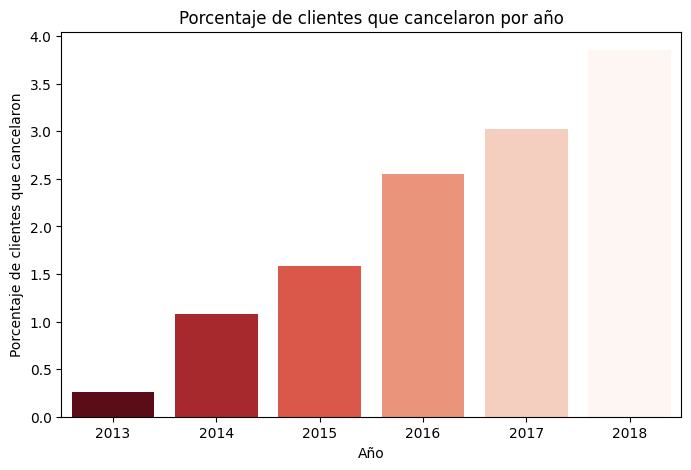

In [58]:
plt.figure(figsize=(8,5))

# Barplot con hue igual al eje x para que se aplique la paleta sin warnings
sns.barplot(
    data=cancelados_por_ano,
    x='cancellation_year',
    y='porcentaje',
    hue='cancellation_year',  # asignamos hue para que la paleta funcione
    palette='Reds_r',
    dodge=False,              # evita separar las barras
    legend=False              # oculta la leyenda
)

plt.ylabel('Porcentaje de clientes que cancelaron')
plt.xlabel('Año')
plt.title('Porcentaje de clientes que cancelaron por año')
plt.show()

Las cancelaciones van en aumento, alcanzando su maxima en 2018. Aun así, el porcentaje es muy bajo en comparacion con la cantidad de clientes, ya que va de 0.25 a 3.85 % del total
Los principales meses de cancelacion son noviembre y diciembre, entiendo que irá ligado a que ser final de año, y julio y agosto, que coincide normalmente con fin de periodo vacacional de verano, o también podria ser final de temporada. Para tener más datos tendríamos que consultar a la empresa y ver si en esos años y esps meses pasó algo fuera de lo común.
Aun así, son un porcentaje realmente bajo.
Me gustaria saber si tiene relacion con el origen de los usuarios

In [59]:
# Total de clientes por provincia
total_por_provincia = df_history.groupby('province')['loyalty_number'].nunique().reset_index(name='total_clientes')

# Cancelaciones por provincia
cancelaciones_por_provincia = (
    df_cancelados
    .groupby('province')['loyalty_number']
    .nunique()
    .reset_index(name='clientes_cancelados')
)

# Combinar y calcular porcentaje
cancelaciones_por_provincia = cancelaciones_por_provincia.merge(total_por_provincia, on='province')
cancelaciones_por_provincia['porcentaje_cancelaciones'] = (cancelaciones_por_provincia['clientes_cancelados'] / cancelaciones_por_provincia['total_clientes']) * 100

# Ordenar de mayor a menor
cancelaciones_por_provincia = cancelaciones_por_provincia.sort_values('porcentaje_cancelaciones', ascending=False)

cancelaciones_por_provincia

,province,clientes_cancelados,total_clientes,porcentaje_cancelaciones
7,Prince Edward Island,11,66,16.666667
2,Manitoba,100,658,15.197568
4,Newfoundland,38,258,14.728682
0,Alberta,122,969,12.590299
8,Quebec,413,3300,12.515152
6,Ontario,674,5404,12.472243
9,Saskatchewan,50,409,12.224939
1,British Columbia,522,4409,11.839419
5,Nova Scotia,58,518,11.196911
10,Yukon,12,110,10.909091


Las provincias pequeñas como Prince Edward Island, Manitoba y Newfoundland muestran los porcentajes más altos, pero esto puede estar influenciado porque tienen un menos numero de clientes. Esto eleva mucho el porcentaje de cancelaciones.

Provincias grandes como Ontario, Quebec, British Columbia tienen porcentajes más bajos comparativamente, pero en términos absolutos el número de cancelaciones es mucho mayor.


In [60]:
# Total de clientes global
total_clientes_global = df_history['loyalty_number'].nunique()

# Cancelaciones por provincia
cancelaciones_global = (
    df_cancelados
    .groupby('province')['loyalty_number']
    .nunique()
    .reset_index(name='clientes_cancelados')
)

# Calcular porcentaje sobre el total global
cancelaciones_global['porcentaje_sobre_total'] = (cancelaciones_global['clientes_cancelados'] / total_clientes_global) * 100

# Ordenar de mayor a menor
cancelaciones_global = cancelaciones_global.sort_values('porcentaje_sobre_total', ascending=False)

cancelaciones_global

,province,clientes_cancelados,porcentaje_sobre_total
6,Ontario,674,4.027006
1,British Columbia,522,3.118839
8,Quebec,413,2.467587
0,Alberta,122,0.728924
2,Manitoba,100,0.597479
3,New Brunswick,67,0.400311
5,Nova Scotia,58,0.346538
9,Saskatchewan,50,0.298739
4,Newfoundland,38,0.227042
10,Yukon,12,0.071697


las provincias grandes concentran la mayor parte de las cancelaciones: Ontario, British Columbia y Quebec.
Las provincias pequeñas, aunque tengan un porcentaje alto dentro de su propio grupo, apenas impactan en el total global (Prince Edward Island y Yukon menos del 0,1 %).

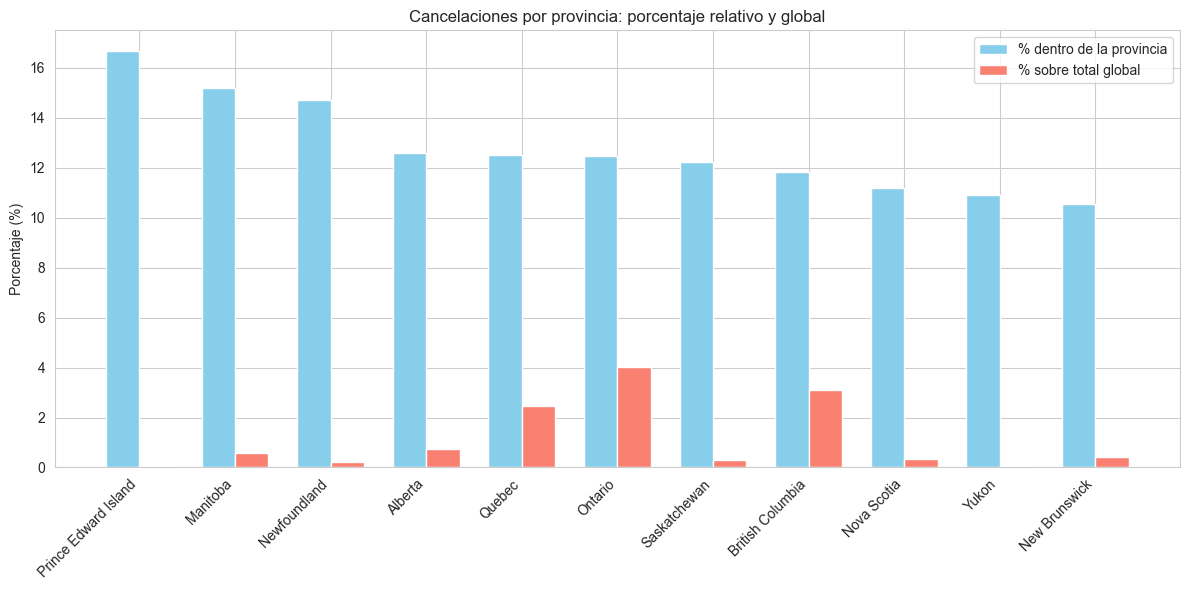

In [61]:
# prueba grafico con los dos resultados



df_por_provincia = pd.DataFrame({
    'province': [
        'Prince Edward Island','Manitoba','Newfoundland','Alberta','Quebec',
        'Ontario','Saskatchewan','British Columbia','Nova Scotia','Yukon','New Brunswick'
    ],
    'pct_provincia': [16.666667,15.197568,14.728682,12.590299,12.515152,12.472243,
                       12.224939,11.839419,11.196911,10.909091,10.534591],
    'pct_global': [0.065723,0.597479,0.227042,0.728924,2.467587,4.027006,
                   0.298739,3.118839,0.346538,0.071697,0.400311]
})

# Configuración del gráfico
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

# Posiciones para las barras
import numpy as np
x = np.arange(len(df_por_provincia))
width = 0.35

# Barras
plt.bar(x - width/2, df_por_provincia['pct_provincia'], width, label='% dentro de la provincia', color='skyblue')
plt.bar(x + width/2, df_por_provincia['pct_global'], width, label='% sobre total global', color='salmon')

# Etiquetas y formato
plt.xticks(x, df_por_provincia['province'], rotation=45, ha='right')
plt.ylabel('Porcentaje (%)')
plt.title('Cancelaciones por provincia: porcentaje relativo y global')
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
# Une los dos conjuntos de datos de la forma más eficiente

# 1. guaedar cada uno limpio

df_history.to_csv("df_history_clean.csv", index=False)
df_activity.to_csv("df_activity_clean.csv", index=False)


In [63]:
# 2. juntar en un documento unico

# Cargar los CSV limpios
df1 = pd.read_csv('df_history_clean.csv')  
df2 = pd.read_csv('df_activity_clean.csv')  

# Asegurar que la columna para merge tenga el mismo nombre y tipo
df1['loyalty_number'] = df1['loyalty_number'].astype(str)
df2['loyalty_number'] = df2['loyalty_number'].astype(str)

# Merge por 'loyalty_number'
df_combined = pd.merge(df1, df2, on='loyalty_number', how='outer')

# Verificar el resultado
print(df_combined.info())
print(df_combined.head(10))

# Guardar CSV combinado
df_combined.to_csv('documentos_unidos.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403760 entries, 0 to 403759
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loyalty_number               403760 non-null  object 
 1   country                      403760 non-null  object 
 2   province                     403760 non-null  object 
 3   city                         403760 non-null  object 
 4   postal_code                  403760 non-null  object 
 5   gender                       403760 non-null  object 
 6   education                    403760 non-null  object 
 7   salary                       403760 non-null  float64
 8   marital_status               403760 non-null  object 
 9   loyalty_card                 403760 non-null  object 
 10  clv                          403760 non-null  float64
 11  enrollment_type              403760 non-null  object 
 12  enrollment_year              403760 non-null  int64  
 13 

In [64]:
df_combined.head(10)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,is_active,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8,Activo,Activo,1,2017,1,3,0,3,1521,152.0,0.0,0
1,100018,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8,Activo,Activo,1,2017,2,2,2,4,1320,132.0,0.0,0
2,100018,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8,Activo,Activo,1,2018,10,6,4,10,3110,311.0,385.0,31
3,100018,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8,Activo,Activo,1,2017,4,4,0,4,924,92.0,0.0,0
4,100018,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8,Activo,Activo,1,2017,5,0,0,0,0,0.0,0.0,0
5,100018,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8,Activo,Activo,1,2017,6,4,1,5,4330,433.0,0.0,0
6,100018,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8,Activo,Activo,1,2017,7,10,0,10,3870,387.0,0.0,0
7,100018,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8,Activo,Activo,1,2017,9,9,4,13,1651,165.0,0.0,0
8,100018,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8,Activo,Activo,1,2017,8,10,5,15,4200,420.0,690.0,56
9,100018,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8,Activo,Activo,1,2017,10,6,0,6,1032,103.0,0.0,0
